In [1]:
from tc_size_rainfall.config import FIGURE_DIR, DATA_DIR, RAW_DIR, PROCESSED_DIR, OUTPUT_DIR
from tc_size_rainfall.geospatial import configurar_mapa

In [2]:
# 0. Preparación de ambientes necesarios

# Importar librerias
import pandas as pd
import xarray as xr
import numpy as np

import os
import errno
import geopandas as gpd
import seaborn as sns


import shapely
from shapely.geometry import shape, Polygon, Point, MultiPoint, box, LineString

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

import cartopy
from cartopy import config
import cartopy.crs as ccrs
from cartopy.io.shapereader import Reader as sf
import cartopy.feature as cfeature


from mpl_toolkits.axes_grid1 import make_axes_locatable


from cmcrameri import cm

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D
from cmcrameri import cm as ccm

In [3]:

# Extremos dentro de ciclones tropicales archivos para pacifico y atlantico
ext_na = pd.read_csv(PROCESSED_DIR / 'resultados_extremos_total_na.csv')
ext_ep = pd.read_csv(PROCESSED_DIR / 'resultados_extremos_total_ep.csv')
extremos = pd.concat([ext_na,ext_ep], ignore_index  =True)

In [4]:
td_na = ext_na[ext_na.MWS < 63]                                # Depresión Tropical
tt_na = ext_na[(ext_na.MWS >= 63) & (ext_na.MWS < 118)]        # Tormenta Tropical
h1_2_na = ext_na[(ext_na.MWS >= 118) & (ext_na.MWS <= 177)]      # Huracanes Cat 1-2
h3_5_na = ext_na[ext_na.MWS >= 177]                             # Huracanes Cat 3-5

# Cuenca: Pacífico Este
td_ep = ext_ep[ext_ep.MWS < 63]
tt_ep = ext_ep[(ext_ep.MWS >= 63) & (ext_ep.MWS < 118)]
h1_2_ep = ext_ep[(ext_ep.MWS >= 118) & (ext_ep.MWS < 177)]
h3_5_ep = ext_ep[ext_ep.MWS >= 177]

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import BoundaryNorm, ListedColormap
import matplotlib.patches as patches
import cmcrameri.cm as cmc

def plot_distance_quadrant_panel(dfs, col_titles, row_labels, cmap_name='lipari_r'):
    assert len(dfs) == 8, "Se requieren exactamente 8 DataFrames"
    assert len(col_titles) == 4, "Se requieren 4 títulos de columna"
    assert len(row_labels) == 2, "Se requieren 2 etiquetas de fila"

    fig, axes = plt.subplots(2, 4, subplot_kw={'projection': 'polar'}, figsize=(20, 10))
    bins = [0, 200, 400, 600, 800, 1000, np.inf]
    distance_labels = ['a', 'b', 'c', 'd', 'e', 'f']
    boundaries = np.arange(0, 52, 3)

    cmap_base = getattr(cmc, cmap_name)
    cmap_discreto = ListedColormap(cmap_base(np.linspace(0, 1, len(boundaries) - 1)))
    norm = BoundaryNorm(boundaries, cmap_discreto.N)

    axes = np.array(axes)

    for idx, ax in enumerate(axes.flatten()):
        # ax.spines['polar'].set_visible(False)
        df = dfs[idx].copy()
        df.loc[:, 'dist_interval'] = pd.cut(df['r'], bins=bins, labels=distance_labels, right=False)
        dist_counts = df.groupby(['cuadrante', 'dist_interval'], observed=False).size().unstack(fill_value=0)
        dist_percentages = dist_counts.div(dist_counts.sum(axis=1), axis=0) * 100

        for i in [1, 2, 3, 4]:
            if i in dist_percentages.index:
                quadrant_data = dist_percentages.loc[i].reindex(distance_labels, fill_value=0)
            else:
                quadrant_data = pd.Series([0] * len(distance_labels), index=distance_labels)

            percentages = quadrant_data.values
            fractions = percentages / 100.0

            left_angle = (i - 1) * (np.pi / 2)
            width = np.pi / 2
            bottom = 0

            # Ahora, la altura de cada anillo es constante (igual) y solo cambiamos el color
            constant_height = 1 / len(distance_labels)  # altura constante para cada anillo

            for j, p in enumerate(percentages):
                color = cmap_discreto(norm(p))
                ax.bar(
                    x=left_angle,
                    height=constant_height,
                    width=width,
                    bottom=bottom,
                    color=color,
                    edgecolor='k',
                    linewidth=1.0,
                    align='edge'
                )
                bottom += constant_height  # sumamos la altura constante para el siguiente anillo

        ax.set_ylim(0, 1)
        ax.set_yticks([])
        ax.set_xticks([])

        # ax.add_patch(patches.Rectangle(
        #     (-np.pi, 0), 2 * np.pi, 1, transform=ax.transData,
        #     fill=False, edgecolor='white', linewidth=2, zorder=10
        # ))

    # Títulos por columna
    for col in range(4):
        axes[0, col].set_title(col_titles[col], fontsize=20, pad=30)

    # Etiquetas por fila
    for row in range(2):
        fig.text(
            0.06,
            0.76 - row * 0.42,
            row_labels[row],
            fontsize=20,
            va='center',
            rotation='vertical'
        )

    # Ajustar layout para dejar espacio para colorbar
    plt.subplots_adjust(bottom=0.15, top=0.92, left=0.1, right=0.95, hspace=0.3, wspace=0.2)

    # Barra de color debajo de todo
    cbar_ax = fig.add_axes([0.2, 0.05, 0.6, 0.03])
    sm = ScalarMappable(norm=norm, cmap=cmap_discreto)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal', extend = 'max')
    cbar.set_label("Percentaje (%)", fontsize=20)
    cbar.set_ticks(boundaries)
    cbar.ax.tick_params(labelsize=20)
    for boundary in boundaries:
        cbar.ax.axvline(x=boundary, color='black', linewidth=1)

    # fig.savefig("figure_5.jpeg", dpi= 300, bbox_inches='tight')


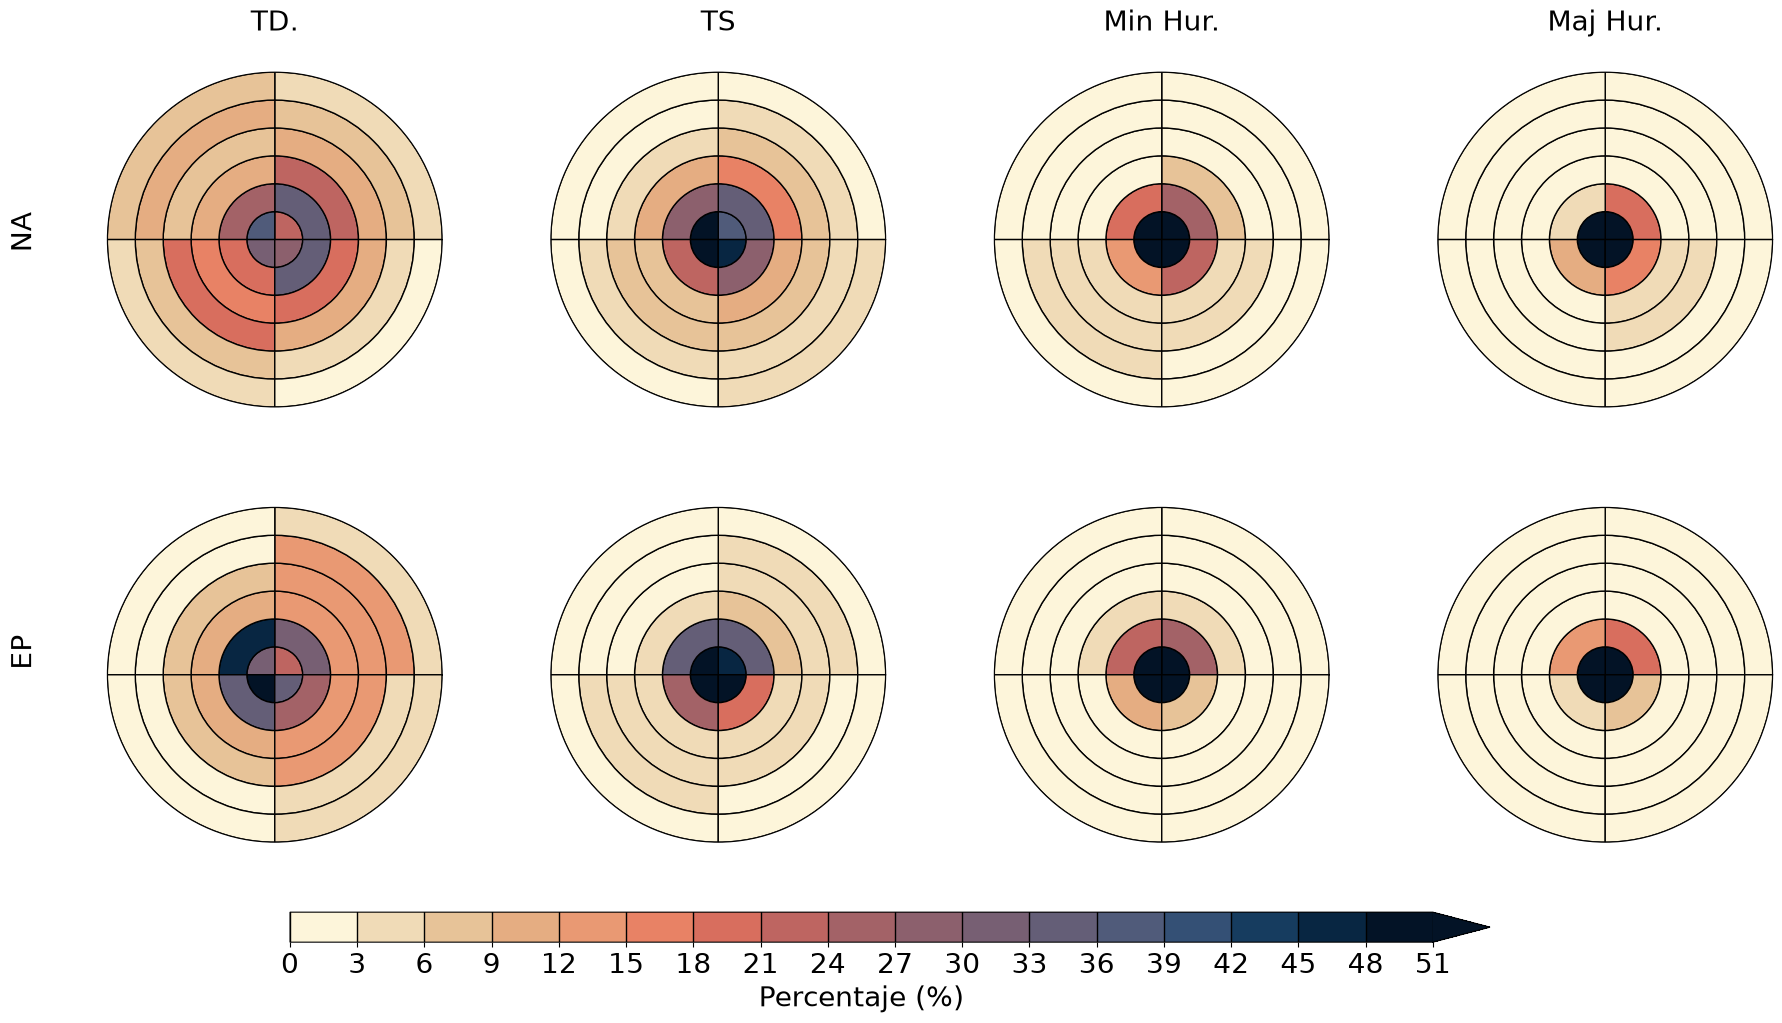

In [6]:
# Suponiendo que tienes 8 DataFrames filtrados:
dfs = [td_na, tt_na, h1_2_na, h3_5_na, td_ep, tt_ep, h1_2_ep, h3_5_ep]
# Títulos por columna (ej. tipo de ciclón, categoría, etc.)
col_titles = ["TD.", "TS", "Min Hur.", "Maj Hur."]

# Etiquetas por fila (ej. Época seca, Época húmeda)
row_labels = ["NA", "EP"]

plot_distance_quadrant_panel(dfs, col_titles, row_labels)